# MSI Pipeline - Script 03: Preprocessing & Quality Control

This notebook performs quality control, normalization, and filtering on MSI AnnData objects.

## Features
- **Normalization options**: RobustScaler, z-score, TIC, log transform, or none
- **QC metrics**: Total intensity per pixel, channel statistics, outlier detection
- **Filtering**: Remove low-quality pixels and channels with poor signal

## Input
- AnnData files from script02 (`{sample_id}.h5ad`)

## Output
- Normalized AnnData files
- QC reports (CSV)
- QC visualizations (PNG)

In [42]:
import sys
from pathlib import Path
import logging

import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directory for imports
sys.path.insert(0, str(Path.cwd().parent))

from utils import normalization as msi_norm
from utils import io as msi_io

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Plot settings
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

## Configuration

In [43]:
# === CONFIGURE THESE PATHS ===

# Base data directory
BASE_DIR = Path(r"T:/Data/124_Maitra_Lab/MSI/" )
#"T:/Sammy Data/Third set results/")  # Path.home() / "ext_hd_sammy"

# Input: AnnData files from script02
INPUT_DIR = BASE_DIR / "out_anndata_peptides" #_normal"  #"metabolites_normal"
#INPUT_DIR = BASE_DIR / "projects" / "out" / "out_msi" / "glycans_h5ad"

# Output directories
OUTPUT_DIR = BASE_DIR / "peptides_h5ad_processed"
QC_DIR = BASE_DIR / "qc_reports"

# Normalization method
NORMALIZATION = "robust"  # Options: robust, zscore, log, tic, none

# RobustScaler parameters (if using robust normalization)
ROBUST_QUANTILE_RANGE = (0.05, 0.95)

# Filtering thresholds (percentiles)
MIN_TOTAL_INTENSITY_PERCENTILE = 1  # Remove bottom 1% by total intensity
MAX_TOTAL_INTENSITY_PERCENTILE = 99  # Remove top 1% by total intensity
MIN_CHANNEL_NONZERO_PCT = 1.0  # Remove channels with <1% non-zero pixels

# Create output directories
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
QC_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input directory: {INPUT_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"QC directory: {QC_DIR}")
print(f"Normalization: {NORMALIZATION}")

Input directory: T:\Data\124_Maitra_Lab\MSI\out_anndata_peptides
Output directory: T:\Data\124_Maitra_Lab\MSI\peptides_h5ad_processed
QC directory: T:\Data\124_Maitra_Lab\MSI\qc_reports
Normalization: robust


## Discover Samples

In [44]:
# Find all h5ad files
sample_files = list(INPUT_DIR.glob("*.h5ad"))
sample_ids = [f.stem for f in sample_files]

print(f"Found {len(sample_ids)} samples:")
for sid in sample_ids:
    print(f"  - {sid}")

Found 41 samples:
  - ADGC427 Donor PanIN manual peptides
  - AIJ3310 A5 Donor PanIN manual peptides
  - AJBV085 A2 Donor PanIN manual peptides
  - AJEF334 C Donor PanIN manual peptides
  - AJEF397 Donor PanIN manual peptides
  - AKDB088 Donor PanIN manual peptides
  - AKDY177 Donor PanIN manual peptides
  - ALAW101 Donor PanIN manual peptides
  - ALBI008 Donor PanIN manual peptides
  - ALBJ267 Donor PanIN manual peptides
  - ALBT459 Donor PanIN manual peptides
  - ALC1306 Donor PanIN manual peptides
  - ALCR447 Donor PanIN manual peptides
  - ALDG405 Donor PanIN manual peptides
  - ALEA056 Donor PanIN manual peptides
  - ALFD148 Donor PanIN manual peptides
  - ALFD156 Donor PanIN manual peptides
  - ALFE122 Donor PanIN manual peptides
  - ALFZ180 Donor PanIN manual peptides
  - ALGB036 Donor PanIN manual peptides
  - ALGV252 Donor PanIN manual peptides
  - ALGW465 Donor PanIN manual peptides
  - ALGY401 Donor PanIN manual peptides
  - N100 NF1173B Donor PanIN manual peptides
  - N11 D

## Load and Inspect Sample

In [45]:
# Load first sample for inspection
if sample_files:
    sample_file = sample_files[0]
    sample_id = sample_file.stem
    
    print(f"Loading {sample_id}...")
    adata = ad.read_h5ad(sample_file)
    
    print(f"\nShape: {adata.shape}")
    print(f"Memory usage: {adata.X.nbytes / 1e6:.1f} MB")

Loading ADGC427 Donor PanIN manual peptides...

Shape: (88946, 924)
Memory usage: 328.7 MB


## Compute QC Metrics

In [46]:
def compute_pixel_qc(adata):
    """Compute per-pixel QC metrics."""
    X = adata.X if not hasattr(adata.X, 'toarray') else adata.X.toarray()
    
    adata.obs['total_intensity'] = X.sum(axis=1)
    adata.obs['n_channels_detected'] = (X > 0).sum(axis=1)
    adata.obs['mean_intensity'] = X.mean(axis=1)
    adata.obs['max_intensity'] = X.max(axis=1)
    
    return adata


def compute_channel_qc(adata):
    """Compute per-channel QC metrics."""
    X = adata.X if not hasattr(adata.X, 'toarray') else adata.X.toarray()
    
    channel_metrics = msi_norm.compute_qc_metrics(X, list(adata.var_names))
    
    # Add to var
    for col in channel_metrics.columns:
        if col != 'feature':
            adata.var[col] = channel_metrics.set_index('feature')[col]
    
    return adata, channel_metrics

In [47]:
# Compute QC metrics
adata = compute_pixel_qc(adata)
adata, channel_metrics = compute_channel_qc(adata)

print("Pixel QC summary:")
print(adata.obs[['total_intensity', 'n_channels_detected', 'mean_intensity']].describe())

print("\nChannel QC summary:")
print(channel_metrics.describe())

Pixel QC summary:
       total_intensity  n_channels_detected  mean_intensity
count          88946.0         88946.000000    88946.000000
mean        14782507.0           637.183212    15998.383789
std          2264114.0            58.405745     2450.339844
min          7306384.0           410.000000     7907.341797
25%         13506485.0           607.000000    14617.407959
50%         15204692.5           653.000000    16455.294922
75%         16336609.0           680.000000    17680.312500
max         24051704.0           774.000000    26029.982422

Channel QC summary:
               mean           std        median    min      max  pct_nonzero  \
count    924.000000    924.000000    924.000000  924.0    924.0   924.000000   
mean   15998.384639  15352.733091  12106.679654    0.0  65535.0    68.959222   
std     4913.949027   1066.102045   6868.729756    0.0      0.0    17.587476   
min     2117.497156   9786.989484      0.000000    0.0  65535.0     5.550559   
25%    13336.371832  

## QC Visualizations

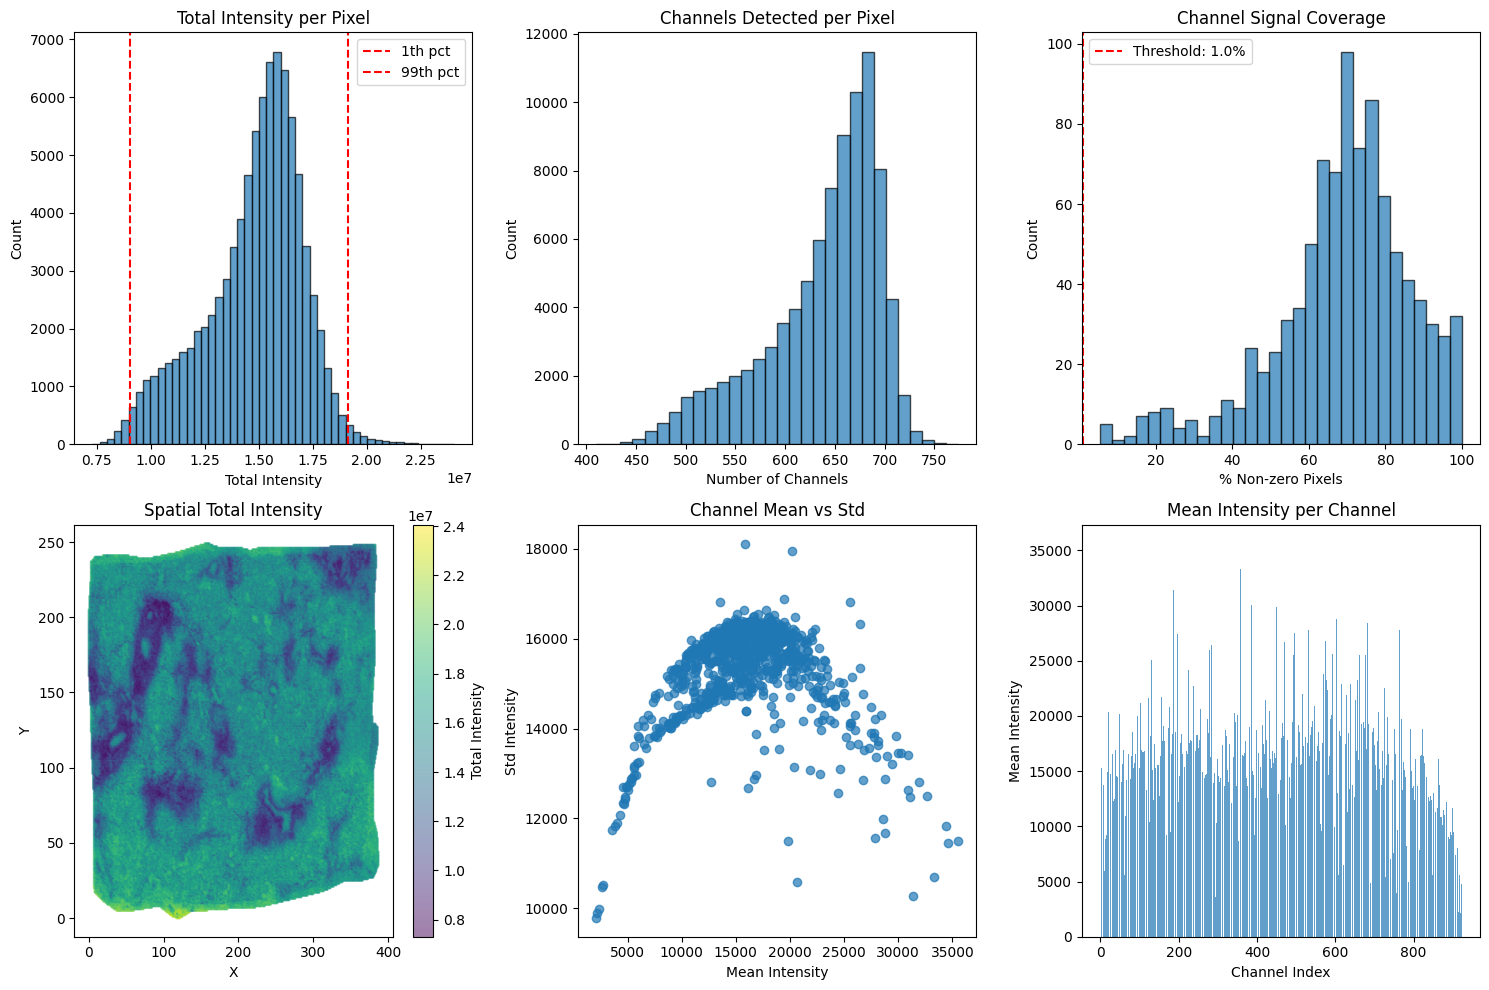

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Total intensity distribution
ax = axes[0, 0]
ax.hist(adata.obs['total_intensity'], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(np.percentile(adata.obs['total_intensity'], MIN_TOTAL_INTENSITY_PERCENTILE), 
           color='r', linestyle='--', label=f'{MIN_TOTAL_INTENSITY_PERCENTILE}th pct')
ax.axvline(np.percentile(adata.obs['total_intensity'], MAX_TOTAL_INTENSITY_PERCENTILE), 
           color='r', linestyle='--', label=f'{MAX_TOTAL_INTENSITY_PERCENTILE}th pct')
ax.set_xlabel('Total Intensity')
ax.set_ylabel('Count')
ax.set_title('Total Intensity per Pixel')
ax.legend()

# Channels detected distribution
ax = axes[0, 1]
ax.hist(adata.obs['n_channels_detected'], bins=30, edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of Channels')
ax.set_ylabel('Count')
ax.set_title('Channels Detected per Pixel')

# Channel % non-zero
ax = axes[0, 2]
ax.hist(channel_metrics['pct_nonzero'], bins=30, edgecolor='black', alpha=0.7)
ax.axvline(MIN_CHANNEL_NONZERO_PCT, color='r', linestyle='--', label=f'Threshold: {MIN_CHANNEL_NONZERO_PCT}%')
ax.set_xlabel('% Non-zero Pixels')
ax.set_ylabel('Count')
ax.set_title('Channel Signal Coverage')
ax.legend()

# Spatial distribution of total intensity
ax = axes[1, 0]
scatter = ax.scatter(adata.obsm['spatial'][:, 0], adata.obsm['spatial'][:, 1], 
                     c=adata.obs['total_intensity'], s=1, cmap='viridis', alpha=0.5)
plt.colorbar(scatter, ax=ax, label='Total Intensity')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Spatial Total Intensity')

# Channel mean vs std
ax = axes[1, 1]
ax.scatter(channel_metrics['mean'], channel_metrics['std'], alpha=0.7)
ax.set_xlabel('Mean Intensity')
ax.set_ylabel('Std Intensity')
ax.set_title('Channel Mean vs Std')

# Mean intensity distribution per channel
ax = axes[1, 2]
ax.bar(range(len(channel_metrics)), channel_metrics['mean'].values, alpha=0.7)
ax.set_xlabel('Channel Index')
ax.set_ylabel('Mean Intensity')
ax.set_title('Mean Intensity per Channel')

plt.tight_layout()
plt.savefig(QC_DIR / f"{sample_id}_qc_plots.png", dpi=150, bbox_inches='tight')
plt.show()

## Filtering

In [49]:
def filter_pixels(adata, min_percentile=1, max_percentile=99):
    """Filter pixels based on total intensity percentiles."""
    X = adata.X if not hasattr(adata.X, 'toarray') else adata.X.toarray()
    
    # Use total intensity if available, otherwise compute
    if 'total_intensity' not in adata.obs:
        total_intensity = X.sum(axis=1)
    else:
        total_intensity = adata.obs['total_intensity'].values
    
    # Create mask
    mask = msi_norm.filter_by_intensity(
        X, 
        min_percentile=min_percentile,
        max_percentile=max_percentile
    )
    
    n_before = adata.n_obs
    adata_filtered = adata[mask, :].copy()
    n_after = adata_filtered.n_obs
    
    logger.info(f"Filtered pixels: {n_before} -> {n_after} ({n_before - n_after} removed)")
    
    return adata_filtered


def filter_channels(adata, min_nonzero_pct=1.0):
    """Filter channels based on signal coverage."""
    X = adata.X if not hasattr(adata.X, 'toarray') else adata.X.toarray()
    
    pct_nonzero = (X > 0).sum(axis=0) / X.shape[0] * 100
    mask = pct_nonzero >= min_nonzero_pct
    
    n_before = adata.n_vars
    adata_filtered = adata[:, mask].copy()
    n_after = adata_filtered.n_vars
    
    logger.info(f"Filtered channels: {n_before} -> {n_after} ({n_before - n_after} removed)")
    
    return adata_filtered

In [50]:
# Store raw data
adata.raw = adata.copy()

print(f"Before filtering: {adata.shape}")

# Filter pixels
adata_filtered = filter_pixels(
    adata, 
    min_percentile=MIN_TOTAL_INTENSITY_PERCENTILE,
    max_percentile=MAX_TOTAL_INTENSITY_PERCENTILE
)

# Filter channels
adata_filtered = filter_channels(
    adata_filtered, 
    min_nonzero_pct=MIN_CHANNEL_NONZERO_PCT
)

print(f"After filtering: {adata_filtered.shape}")

Before filtering: (88946, 924)


INFO:__main__:Filtered pixels: 88946 -> 87166 (1780 removed)
INFO:__main__:Filtered channels: 924 -> 924 (0 removed)


After filtering: (87166, 924)


## Normalization

Applying robust normalization...


INFO:utils.normalization:Applied robust normalization


Normalization complete


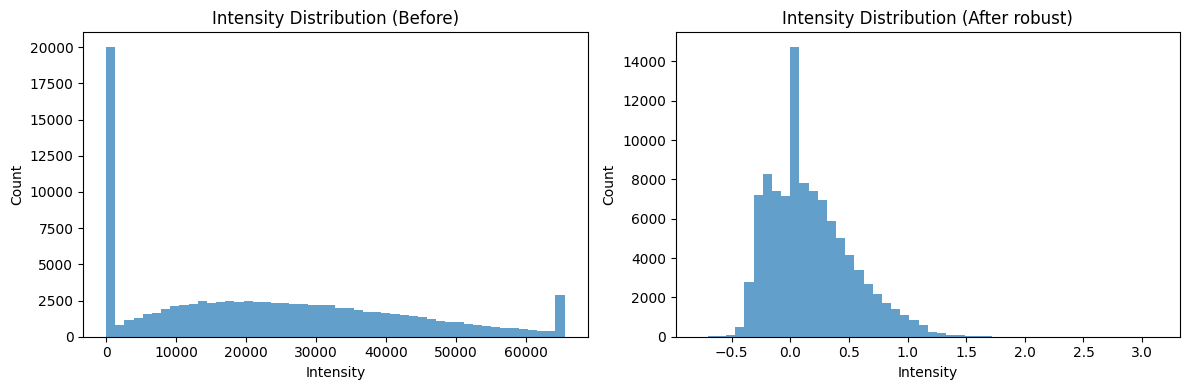

In [51]:
# Apply normalization
if NORMALIZATION != "none":
    print(f"Applying {NORMALIZATION} normalization...")
    
    if NORMALIZATION == "robust":
        msi_norm.normalize_anndata(
            adata_filtered, 
            method='robust',
            quantile_range=ROBUST_QUANTILE_RANGE
        )
    elif NORMALIZATION == "zscore":
        msi_norm.normalize_anndata(adata_filtered, method='zscore')
    elif NORMALIZATION == "log":
        msi_norm.normalize_anndata(adata_filtered, method='log', pseudocount=1.0)
    elif NORMALIZATION == "tic":
        msi_norm.normalize_anndata(adata_filtered, method='tic')
    
    print("Normalization complete")
    
    # Show distribution after normalization
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    ax = axes[0]
    ax.hist(adata.X.flatten()[:100000], bins=50, alpha=0.7, label='Before')
    ax.set_xlabel('Intensity')
    ax.set_ylabel('Count')
    ax.set_title('Intensity Distribution (Before)')
    
    ax = axes[1]
    ax.hist(adata_filtered.X.flatten()[:100000], bins=50, alpha=0.7, label='After')
    ax.set_xlabel('Intensity')
    ax.set_ylabel('Count')
    ax.set_title(f'Intensity Distribution (After {NORMALIZATION})')
    
    plt.tight_layout()
    plt.show()

## Save Processed Data

In [52]:
# Save processed AnnData
# Ensure AnnData metadata is HDF5-serializable
if 'normalization' in adata_filtered.uns:
    params = adata_filtered.uns['normalization'].get('parameters', {})
    if isinstance(params.get('quantile_range'), tuple):
        params['quantile_range'] = list(params['quantile_range'])
    adata_filtered.uns['normalization']['parameters'] = params

output_path = OUTPUT_DIR / f"{sample_id}.h5ad"
adata_filtered.write_h5ad(output_path, compression='gzip')
print(f"Saved to {output_path}")

# Save QC report
qc_report = pd.DataFrame({
    'sample_id': [sample_id],
    'n_pixels_raw': [adata.raw.n_obs if adata.raw else adata.n_obs],
    'n_channels_raw': [adata.raw.n_vars if adata.raw else adata.n_vars],
    'n_pixels_filtered': [adata_filtered.n_obs],
    'n_channels_filtered': [adata_filtered.n_vars],
    'median_total_intensity': [adata.obs['total_intensity'].median()],
    'normalization': [NORMALIZATION],
})

qc_report_path = QC_DIR / f"{sample_id}_qc_summary.csv"
qc_report.to_csv(qc_report_path, index=False)
print(f"QC report saved to {qc_report_path}")

Saved to T:\Data\124_Maitra_Lab\MSI\peptides_h5ad_processed\ADGC427 Donor PanIN manual peptides.h5ad
QC report saved to T:\Data\124_Maitra_Lab\MSI\qc_reports\ADGC427 Donor PanIN manual peptides_qc_summary.csv


## Batch Process All Samples

In [53]:
def process_sample_qc(input_path, output_dir, qc_dir, normalization, 
                      robust_quantile_range, min_pixel_pct, max_pixel_pct,
                      min_channel_pct):
    """Process a single sample through QC pipeline."""
    sample_id = input_path.stem
    logger.info(f"Processing {sample_id}...")
    
    # Load
    adata = ad.read_h5ad(input_path)
    
    # Store raw
    adata.raw = adata.copy()
    
    # Compute QC metrics
    adata = compute_pixel_qc(adata)
    adata, channel_metrics = compute_channel_qc(adata)
    
    # Filter
    adata = filter_pixels(adata, min_percentile=min_pixel_pct, max_percentile=max_pixel_pct)
    adata = filter_channels(adata, min_nonzero_pct=min_channel_pct)
    
    # Normalize
    if normalization != "none":
        if normalization == "robust":
            msi_norm.normalize_anndata(adata, method='robust', quantile_range=robust_quantile_range)
        else:
            msi_norm.normalize_anndata(adata, method=normalization)
    
    # Save
    output_path = output_dir / f"{sample_id}.h5ad"
    adata.write_h5ad(output_path, compression='gzip')
    
    # Save channel QC
    channel_metrics.to_csv(qc_dir / f"{sample_id}_channel_qc.csv", index=False)
    
    return {
        'sample_id': sample_id,
        'n_pixels_raw': adata.raw.n_obs,
        'n_channels_raw': adata.raw.n_vars,
        'n_pixels_filtered': adata.n_obs,
        'n_channels_filtered': adata.n_vars,
        'status': 'success'
    }

In [54]:
# Process all samples
all_results = []

for sample_file in sample_files:
    try:
        result = process_sample_qc(
            input_path=sample_file,
            output_dir=OUTPUT_DIR,
            qc_dir=QC_DIR,
            normalization=NORMALIZATION,
            robust_quantile_range=ROBUST_QUANTILE_RANGE,
            min_pixel_pct=MIN_TOTAL_INTENSITY_PERCENTILE,
            max_pixel_pct=MAX_TOTAL_INTENSITY_PERCENTILE,
            min_channel_pct=MIN_CHANNEL_NONZERO_PCT
        )
        all_results.append(result)
    except Exception as e:
        logger.error(f"Error processing {sample_file.stem}: {e}")
        all_results.append({
            'sample_id': sample_file.stem,
            'status': 'error',
            'error': str(e)
        })

# Summary
summary_df = pd.DataFrame(all_results)
summary_df.to_csv(QC_DIR / "preprocessing_summary.csv", index=False)
print("\nPreprocessing Summary:")
print(summary_df)

INFO:__main__:Processing ADGC427 Donor PanIN manual peptides...
INFO:__main__:Filtered pixels: 88946 -> 87166 (1780 removed)
INFO:__main__:Filtered channels: 924 -> 924 (0 removed)
INFO:utils.normalization:Applied robust normalization
INFO:__main__:Processing AIJ3310 A5 Donor PanIN manual peptides...
INFO:__main__:Filtered pixels: 548807 -> 537829 (10978 removed)
INFO:__main__:Filtered channels: 924 -> 924 (0 removed)
ERROR:__main__:Error processing AIJ3310 A5 Donor PanIN manual peptides: Unable to allocate 3.70 GiB for an array with shape (537829, 924) and data type float64
INFO:__main__:Processing AJBV085 A2 Donor PanIN manual peptides...
INFO:__main__:Filtered pixels: 221855 -> 217417 (4438 removed)
INFO:__main__:Filtered channels: 924 -> 924 (0 removed)
INFO:utils.normalization:Applied robust normalization
INFO:__main__:Processing AJEF334 C Donor PanIN manual peptides...
ERROR:__main__:Error processing AJEF334 C Donor PanIN manual peptides: Unable to allocate 3.05 GiB for an array 


Preprocessing Summary:
                                   sample_id  n_pixels_raw  n_channels_raw  \
0        ADGC427 Donor PanIN manual peptides       87166.0           924.0   
1     AIJ3310 A5 Donor PanIN manual peptides           NaN             NaN   
2     AJBV085 A2 Donor PanIN manual peptides      217417.0           924.0   
3      AJEF334 C Donor PanIN manual peptides           NaN             NaN   
4        AJEF397 Donor PanIN manual peptides       70331.0           924.0   
5        AKDB088 Donor PanIN manual peptides       57764.0           924.0   
6        AKDY177 Donor PanIN manual peptides       75371.0           924.0   
7        ALAW101 Donor PanIN manual peptides       82074.0           924.0   
8        ALBI008 Donor PanIN manual peptides       36532.0           924.0   
9        ALBJ267 Donor PanIN manual peptides       64995.0           924.0   
10       ALBT459 Donor PanIN manual peptides       60030.0           924.0   
11       ALC1306 Donor PanIN manual pept